# Sprint 6 – Part 2

# Encoders & Scalers

## Objective

The objective of this notebook is to understand different encoding and scaling techniques used in machine learning.

Instead of memorizing preprocessing functions, this notebook focuses on understanding when, why, and how each technique should be used.

In [2]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

df = pd.read_csv("../data/interim/featured_ford.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age,mileage_per_year,engine_category,fuel_efficiency,tax_category,price_segment
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0,9,1594.400000,small,medium,medium,Premium
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0,8,1009.222222,small,medium,medium,Premium
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0,9,1245.600000,small,medium,medium,Premium
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5,7,1307.500000,medium,medium,medium,Luxury
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0,7,185.250000,small,medium,medium,Luxury


In [16]:
le =LabelEncoder()

df["fuel_label"] = le.fit_transform(df["fuelType"])
df[["fuelType","fuel_label"]].head()


,fuelType,fuel_label
0,Petrol,4
1,Petrol,4
2,Petrol,4
3,Petrol,4
4,Petrol,4


In [17]:
ohe = OneHotEncoder(
    sparse_output=False
)
fuel = ohe.fit_transform(
    df[["fuelType"]]
)
fuel

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.]], shape=(17966, 5))

In [18]:
fuel_df = pd.DataFrame(
    fuel,
    columns=ohe.get_feature_names_out()
)

fuel_df.head()

,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,1.0


In [23]:
scaler = StandardScaler()

scaled  = scaler.fit_transform(
    df[["mileage"]]
)

scaled

array([[-0.38099808],
       [-0.73335899],
       [-0.56013157],
       ...,
       [-0.83982222],
       [-0.94269045],
       [-0.94269045]], shape=(17966, 1))

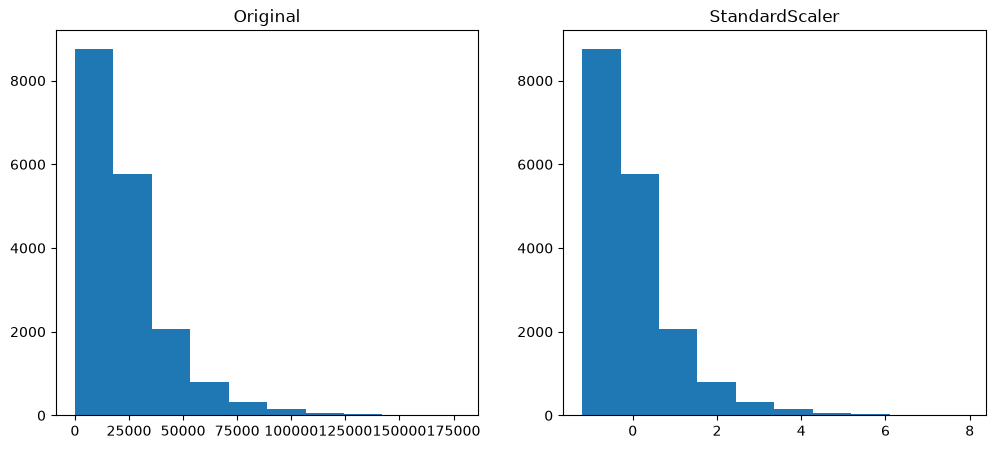

In [24]:
fig , ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

ax[0].hist(df["mileage"])
ax[0].set_title("Original")
ax[1].hist(scaled)
ax[1].set_title("StandardScaler")
plt.show()

In [25]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    df[["mileage"]]
)

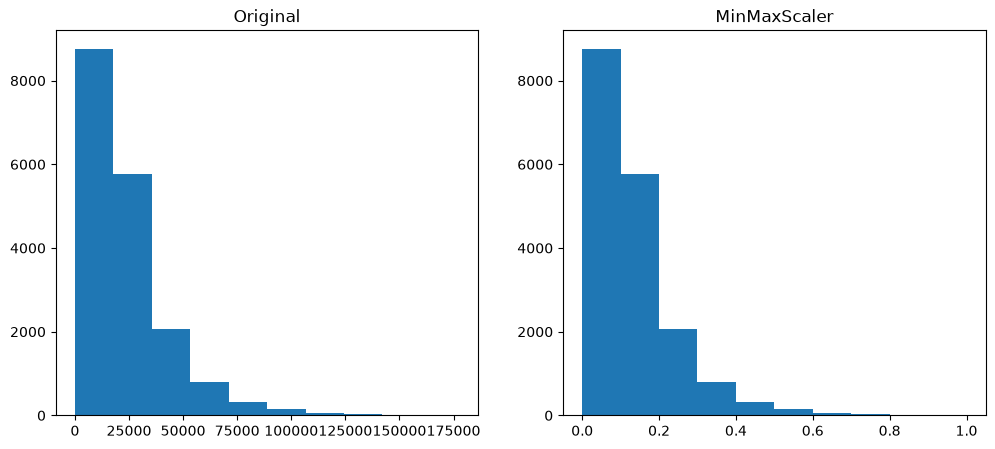

In [26]:
fig , ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

ax[0].hist(df["mileage"])
ax[0].set_title("Original")
ax[1].hist(scaled)
ax[1].set_title("MinMaxScaler")
plt.show()

In [27]:
scaler = RobustScaler()

scaled = scaler.fit_transform(
    df[["mileage"]]
)

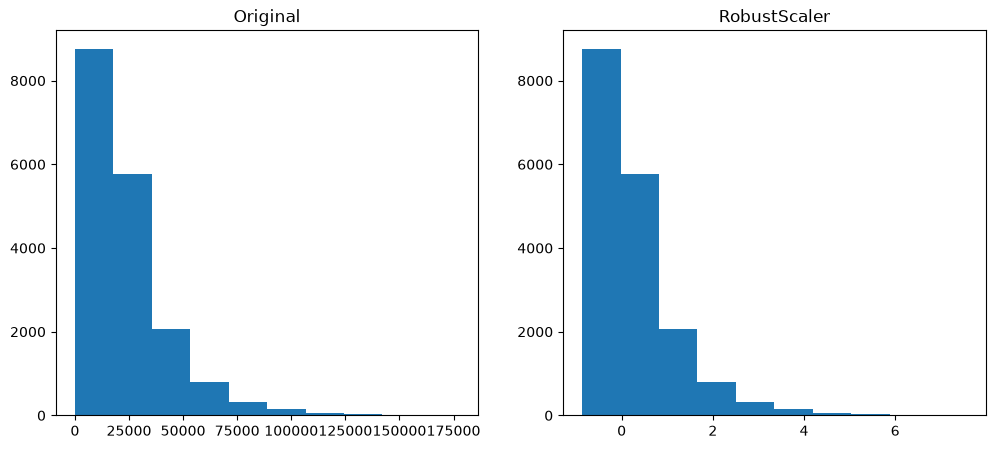

In [31]:
fig , ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

ax[0].hist(df["mileage"])
ax[0].set_title("Original")
ax[1].hist(scaled)
ax[1].set_title("RobustScaler")

plt.show()

Text(0.5, 1.0, 'MinMax Scaler')

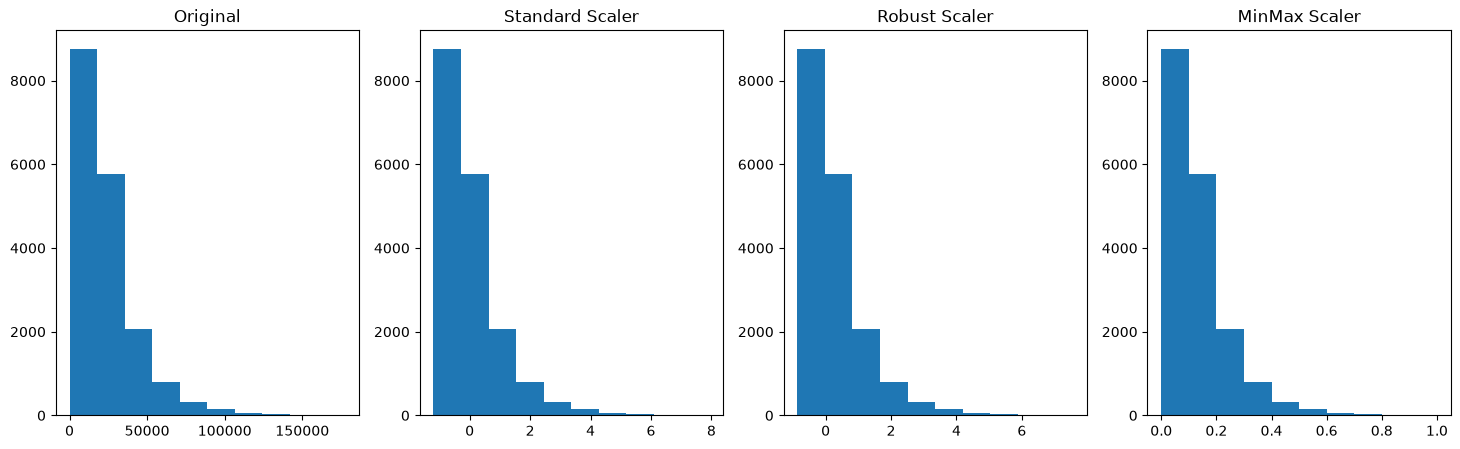

In [37]:
fig,ax = plt.subplots(
    1,4,figsize=(18,5)
)

ax[0].hist(df["mileage"])
ax[0].set_title("Original")


ax[1].hist(StandardScaler().fit_transform(df[["mileage"]]))
ax[1].set_title("Standard Scaler")

ax[2].hist(RobustScaler().fit_transform(df[["mileage"]]))
ax[2].set_title("Robust Scaler")

ax[3].hist(MinMaxScaler().fit_transform(df[["mileage"]]))
ax[3].set_title("MinMax Scaler")
